In [1]:
import numpy as np
import matplotlib.pyplot as plt
import util
import Hybrid


In [2]:
# Room configuration

x_wall1 = 0
x_wall2 = 10
y_wall3 = 0
y_wall4 = 10

walls = np.array([[x_wall1, x_wall2], [y_wall3, y_wall4]])

In [3]:
Rx = np.array([5, 5])  # Receiver position

Tx1 = np.array([8, 8])
Tx2 = np.array([2, 2])
Tx3 = np.array([2, 8])
Tx4 = np.array([8, 2])

Txs = [Tx1, Tx2, Tx3, Tx4]

In [11]:
# Angle identification

def get_angle(Rx, Tx):
    """
    Calculate the angle at the receiver (Rx) given the transmitter (Tx) position.
    """
    delta = Tx - Rx
    angle = np.arctan2(delta[1], delta[0])  # Angle in radians
    return angle


def find_reflection_point(receiver, target, x_wall=None, y_wall=None):

    x1, y1 = receiver
    x2, y2 = target

    if x_wall is not None:

        y_r = (y1 * (x2 - x_wall) + y2 * (x1 - x_wall)) / (x1 + x2 - 2 * x_wall)
        return (x_wall, y_r)
    
    if y_wall is not None:

        x_r = (x1 * (y2 - y_wall) + x2 * (y1 - y_wall)) / (y1 + y2 - 2 * y_wall)
        return (x_r, y_wall)


def angle_sector(angle):
        # 1: 0 to 90, 2: 90 to 180, 3: -180 to -90, 4: -90 to 0
        return (int(angle // (np.pi/2)) + 4) % 4 + 1


def identify_wall(first_angle, second_angle):

        first_sector = angle_sector(first_angle)
        second_sector = angle_sector(second_angle)

        if first_sector == second_sector:
            if first_sector in [1, 3]:
                if second_angle < first_angle:
                    return 'vertical'
                else:
                    return 'horizontal'
            else:
                if second_angle < first_angle:
                    return 'horizontal'
                else:
                    return 'vertical'
                
        elif first_sector == 1:
            if second_sector == 2:
                return 'vertical'
            elif second_sector == 4:
                return 'horizontal'
        elif first_sector == 2:
            if second_sector == 1:
                return 'vertical'
            elif second_sector == 3:
                return 'horizontal'
        elif first_sector == 3:
            if second_sector == 2:
                return 'horizontal'
            elif second_sector == 4:
                return 'vertical'
        elif first_sector == 4:
            if second_sector == 1:
                return 'horizontal'
            elif second_sector == 3:
                return 'vertical'

        return None  # No wall identified


1
Direct angle: 45.00 degrees
Reflected angles: 167.01, 23.20, -77.01, 66.80 degrees
Orientation 1 : vertical, Orientation 2 : vertical,
Orientation 3 : horizontal, Orientation 4 : horizontal


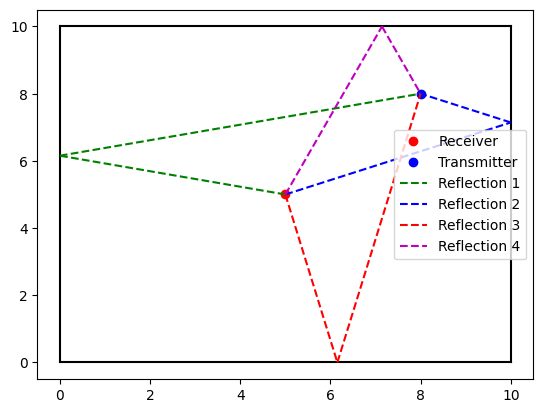

3
Direct angle: -135.00 degrees
Reflected angles: -156.80, -12.99, -113.20, 102.99 degrees
Orientation 1 : vertical, Orientation 2 : vertical,
Orientation 3 : horizontal, Orientation 4 : horizontal


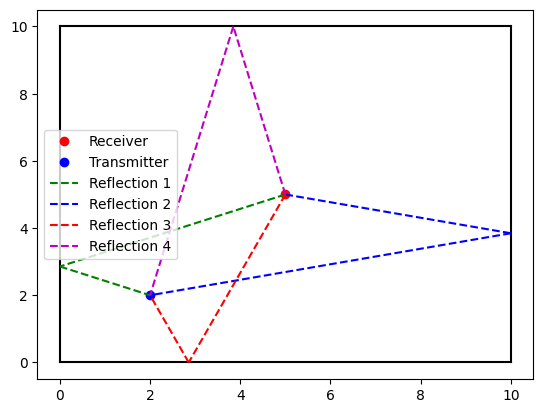

2
Direct angle: 135.00 degrees
Reflected angles: 156.80, 12.99, -102.99, 113.20 degrees
Orientation 1 : vertical, Orientation 2 : vertical,
Orientation 3 : horizontal, Orientation 4 : horizontal


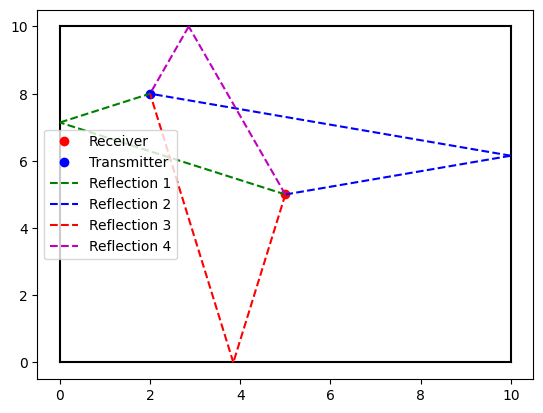

4
Direct angle: -45.00 degrees
Reflected angles: -167.01, -23.20, -66.80, 77.01 degrees
Orientation 1 : vertical, Orientation 2 : vertical,
Orientation 3 : horizontal, Orientation 4 : horizontal


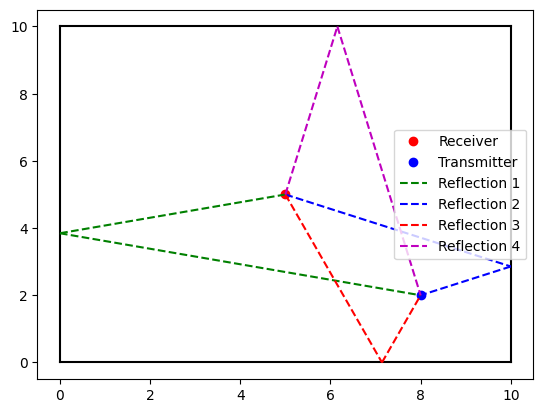

In [20]:
for Tx in Txs:
    direct_angle = get_angle(Rx, Tx)
    print(angle_sector(direct_angle))

    reflection_points = []
    reflection_points.append(find_reflection_point(Rx, Tx, x_wall=x_wall1))
    reflection_points.append(find_reflection_point(Rx, Tx, x_wall=x_wall2))
    reflection_points.append(find_reflection_point(Rx, Tx, y_wall=y_wall3))
    reflection_points.append(find_reflection_point(Rx, Tx, y_wall=y_wall4))

    angle1 = get_angle(Rx, reflection_points[0])
    angle2 = get_angle(Rx, reflection_points[1])
    angle3 = get_angle(Rx, reflection_points[2])
    angle4 = get_angle(Rx, reflection_points[3])

    print(f"Direct angle: {np.degrees(direct_angle):.2f} degrees")
    print(f"Reflected angles: {np.degrees(angle1):.2f}, {np.degrees(angle2):.2f}, {np.degrees(angle3):.2f}, {np.degrees(angle4):.2f} degrees")

    orientation1 = identify_wall(direct_angle, angle1)
    orientation2 = identify_wall(direct_angle, angle2)
    orientation3 = identify_wall(direct_angle, angle3)
    orientation4 = identify_wall(direct_angle, angle4)

    print(f"Orientation 1 : {orientation1}, Orientation 2 : {orientation2},\nOrientation 3 : {orientation3}, Orientation 4 : {orientation4}")

    fig, ax = plt.subplots()

    # Plot walls
    ax.plot([x_wall1, x_wall1], [y_wall3, y_wall4], 'k-')  # Left wall
    ax.plot([x_wall2, x_wall2], [y_wall3, y_wall4], 'k-')  # Right wall
    ax.plot([x_wall1, x_wall2], [y_wall3, y_wall3], 'k-')  # Bottom wall
    ax.plot([x_wall1, x_wall2], [y_wall4, y_wall4], 'k-')  # Top wall

    # Plot receiver and transmitter
    ax.plot(Rx[0], Rx[1], 'ro', label='Receiver')
    ax.plot(Tx[0], Tx[1], 'bo', label='Transmitter')

    # Plot reflected paths
    ax.plot([Rx[0], reflection_points[0][0]], [Rx[1], reflection_points[0][1]], 'g--', label='Reflection 1')
    ax.plot([reflection_points[0][0], Tx[0]], [reflection_points[0][1], Tx[1]], 'g--')
    ax.plot([Rx[0], reflection_points[1][0]], [Rx[1], reflection_points[1][1]], 'b--', label='Reflection 2')
    ax.plot([reflection_points[1][0], Tx[0]], [reflection_points[1][1], Tx[1]], 'b--')
    ax.plot([Rx[0], reflection_points[2][0]], [Rx[1], reflection_points[2][1]], 'r--', label='Reflection 3')
    ax.plot([reflection_points[2][0], Tx[0]], [reflection_points[2][1], Tx[1]], 'r--')
    ax.plot([Rx[0], reflection_points[3][0]], [Rx[1], reflection_points[3][1]], 'm--', label='Reflection 4')
    ax.plot([reflection_points[3][0], Tx[0]], [reflection_points[3][1], Tx[1]], 'm--')
    
    ax.legend()
    plt.show()


    